In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from glob import glob
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
# lightly adapted (variable name changes) from tobac_track_histograms.py in TRACER-PAWS-NEXRAD-LMA

def track_polarimetry(df,    
        zdr_thresh = 0.0,
        kdp_thresh = 0.0,
        flash_thresh = 0.0,
        zdr_var = 'track_zdrwt_avg',
        kdp_var = 'track_kdpwt_avg',
        ltg_var = 'track_flash_count',
    ):
    """
    Calculate the polarimetric column and lightning flash properties of a tracked dataset.
    df: a tracked dataset that has been grouped by feature_parent_track_id, 
                     and then summed over the feature dimension.
    
    Returns (track_membership, counts), a dictionary of DataArrays giving boolean membership of each 
    track in each category, and a pandas DataFrame that is a count of tracks in those categories.
    """

    has_zdr = (df[zdr_var] > zdr_thresh)
    no_zdr = ~has_zdr
    has_kdp = (df[kdp_var] > kdp_thresh)
    no_kdp = ~has_kdp
    has_lightning = (df[ltg_var] > flash_thresh)
    no_lightning = ~has_lightning

    track_membership = dict(
        track_has_zdr_kdp_ltg = (has_kdp & has_zdr & has_lightning),
        track_has_zdr_kdp_only = (has_kdp & has_zdr & no_lightning),
        track_has_zdr_ltg_only = (no_kdp & has_zdr & has_lightning),
        track_has_zdr_only = (no_kdp & has_zdr & no_lightning),
        track_has_nothing = (no_kdp & no_zdr & no_lightning),
        track_has_kdp_only = (has_kdp & no_zdr & no_lightning),
        track_has_kdp_ltg_only = (has_kdp & no_zdr & has_lightning),
        track_has_ltg_only = (no_kdp & no_zdr & has_lightning),
    )
    
    #header = ["nothing","zdr","kdp","kdp_zdr","ltg","kdp_zdr_ltg","kdp_ltg","zdr_ltg"]
    #results_row = np.fromiter(map(sum, 
    #                          [has_nothing,has_zdr_only,has_kdp_only,has_zdr_kdp_only,
    #                           has_ltg_only,has_zdr_kdp_ltg,has_kdp_ltg_only,has_zdr_ltg_only]),
    #                      dtype=int)
    # counts = pd.DataFrame([results_row,], columns=header)
    results = {k:[v.sum().values] for k,v in track_membership.items()}
    counts = pd.DataFrame(results)
    
    
    return track_membership, counts

# new save data

In [47]:
vars_to_keep = ['feature_flash_count',
                'feature_zdrvol', 'feature_kdpvol',
'feature_flash_count_area_time_norm',
'feature_zdrvol_area_time_norm',
'feature_kdpvol_area_time_norm',
'feature_rhvdeficitvol_area_time_norm',
'feature_zdrcol_area_time_norm',
'feature_kdpcol_area_time_norm',
'feature_rhvdeficitcol_area_time_norm',
'feature_zdrcol_total_area_time_norm',
'feature_kdpcol_total_area_time_norm',
'feature_rhvdeficitcol_total_area_time_norm',
'feature_zdrwt_total_area_time_norm',
'feature_kdpwt_total_area_time_norm',
'feature_rhvdeficitwt_total_area_time_norm',
'feature_nearby_count_20km_area_time_norm',
'feature_zdrvol',
'feature_kdpcol',
'feature_rhvdeficitcol',
'feature_nearby_count_5km',
'feature_nearby_count_10km',
'feature_nearby_count_15km',
'feature_nearby_count_20km',
'max_reflectivity'
]

In [48]:
# fn = '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220602/tracksummary_data_track-has-nothing_melt4400.nc'
# ds = xr.open_dataset(fn, decode_timedelta=True)
# ds = ds.drop_dims(['cell', 'track'])[vars_to_keep]

# this_date = fn.split('/')[-2].replace('tobac_Save_','')
# df = ds.to_dataframe().reset_index(names=['track_id'])
# df['date']=this_date
# df = df.set_index(['date', 'track_id'])
# # df

In [49]:
path_to_tobac_Save = '/data/Houston/TRACER_TRACKING_STG/'
this_category = 'track_has_any'
pathstring_all_days = '{1}/tobac_Save_2022*/tracksummary_data_{0}_melt*.nc'.format(this_category.replace('_','-'), path_to_tobac_Save)
track_dss = sorted(glob(pathstring_all_days))
track_dss

['/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220602/tracksummary_data_track-has-any_melt4400.nc',
 '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220604/tracksummary_data_track-has-any_melt4500.nc',
 '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220617/tracksummary_data_track-has-any_melt5000.nc',
 '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220622/tracksummary_data_track-has-any_melt4700.nc',
 '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220702/tracksummary_data_track-has-any_melt5000.nc',
 '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220706/tracksummary_data_track-has-any_melt5000.nc',
 '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220712/tracksummary_data_track-has-any_melt5300.nc',
 '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220713/tracksummary_data_track-has-any_melt4800.nc',
 '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220714/tracksummary_data_track-has-any_melt4900.nc',
 '/data/Houston/TRACER_TRACKING_STG/tobac_Save_20220728/tracksummary_data_track-ha

In [50]:
all_df = []

for tdss in track_dss:
    ds = xr.open_dataset(tdss, decode_timedelta=True).drop_dims(['cell', 'track'])[vars_to_keep]
    this_date = tdss.split('/')[-2].replace('tobac_Save_','')
    df = ds.to_dataframe().reset_index(names=['track_id'])
    df['date']=this_date
    df = df.set_index(['date', 'track_id'])
    all_df.append(df)

df = pd.concat(all_df)

In [51]:
# track_membership, track_counts = track_polarimetry(xr.Dataset(df),
#                   zdr_var = 'feature_zdrwt_total_area_time_norm',
#                   kdp_var = 'feature_kdpwt_total_area_time_norm',
#                   ltg_var = 'feature_flash_count_area_time_norm')

# must use the zdr and kdvol variables, and feature_flash_count, to get the same track counts as the other histos.
# normalizations and so forth give a different meaning of "zero", changing the membership.
track_membership, track_counts = track_polarimetry(xr.Dataset(df),
                  zdr_var = 'feature_zdrvol',
                  kdp_var = 'feature_kdpvol',
                  ltg_var = 'feature_flash_count')

In [52]:
track_counts

,track_has_zdr_kdp_ltg,track_has_zdr_kdp_only,track_has_zdr_ltg_only,track_has_zdr_only,track_has_nothing,track_has_kdp_only,track_has_kdp_ltg_only,track_has_ltg_only
0,351,331,71,1105,5625,4,0,1


In [53]:
100*track_counts/7488

,track_has_zdr_kdp_ltg,track_has_zdr_kdp_only,track_has_zdr_ltg_only,track_has_zdr_only,track_has_nothing,track_has_kdp_only,track_has_kdp_ltg_only,track_has_ltg_only
0,4.6875,4.420406,0.948184,14.756944,75.120192,0.053419,0.0,0.013355


In [54]:
df.columns

Index(['feature_flash_count', 'feature_zdrvol', 'feature_kdpvol',
       'feature_flash_count_area_time_norm', 'feature_zdrvol_area_time_norm',
       'feature_kdpvol_area_time_norm', 'feature_rhvdeficitvol_area_time_norm',
       'feature_zdrcol_area_time_norm', 'feature_kdpcol_area_time_norm',
       'feature_rhvdeficitcol_area_time_norm',
       'feature_zdrcol_total_area_time_norm',
       'feature_kdpcol_total_area_time_norm',
       'feature_rhvdeficitcol_total_area_time_norm',
       'feature_zdrwt_total_area_time_norm',
       'feature_kdpwt_total_area_time_norm',
       'feature_rhvdeficitwt_total_area_time_norm',
       'feature_nearby_count_20km_area_time_norm', 'feature_kdpcol',
       'feature_rhvdeficitcol', 'feature_nearby_count_5km',
       'feature_nearby_count_10km', 'feature_nearby_count_15km',
       'feature_nearby_count_20km', 'max_reflectivity'],
      dtype='object')

In [55]:
df

feature_flash_count  feature_zdrvol  feature_kdpvol  \
date     track_id                                                        
20220602 1                    0.000000           0.000           0.000   
         4                    2.000113         357.375          14.375   
         17                   0.000000           0.000           0.000   
         45                   0.000000           0.000           0.000   
         47                   0.000000           0.000           0.000   
...                                ...             ...             ...   
20220917 740                  0.000000          61.500           2.500   
         743                  0.000000         192.625           0.000   
         746                  0.000000           0.000           0.000   
         748                  0.000000           0.000           0.000   
         753                  0.000000         720.750          70.750   

                   feature_flash_count_area_time_norm  \
date     track_id                                       
20220602 1                               0.000000e+00   
         4                               1.725579e-07   
         17                              0.000000e+00   
         45                              0.000000e+00   
         47                              0.000000e+00   
...                                               ...   
20220917 740                             0.000000e+00   
         743                             0.000000e+00   
         746                             0.000000e+00   
         748                             0.000000e+00   
         753                             0.000000e+00   

                   feature_zdrvol_area_time_norm  \
date     track_id                                  
20220602 1                              0.000000   
         4                              0.000112   
         17                             0.000000   
         45                             0.000000   
         47                             0.000000   
...                                          ...   
20220917 740                            0.000042   
         743                            0.000639   
         746                            0.000000   
         748                            0.000000   
         753                            0.000229   

                   feature_kdpvol_area_time_norm  \
date     track_id                                  
20220602 1                              0.000000   
         4                              0.000001   
         17                             0.000000   
         45                             0.000000   
         47                             0.000000   
...                                          ...   
20220917 740                            0.000002   
         743                            0.000000   
         746                            0.000000   
         748                            0.000000   
         753                            0.000013   

                   feature_rhvdeficitvol_area_time_norm  \
date     track_id                                         
20220602 1                                     0.000000   
         4                                     0.000282   
         17                                    0.000000   
         45                                    0.000000   
         47                                    0.000000   
...                                                 ...   
20220917 740                                   0.000025   
         743                                   0.000225   
         746                                   0.000000   
         748                                   0.000000   
         753                                   0.000091   

                   feature_zdrcol_area_time_norm  \
date     track_id                                  
20220602 1                              0.000000   
         4                          

In [56]:
membership = track_membership['track_has_zdr_kdp_ltg']

In [57]:
df

feature_flash_count  feature_zdrvol  feature_kdpvol  \
date     track_id                                                        
20220602 1                    0.000000           0.000           0.000   
         4                    2.000113         357.375          14.375   
         17                   0.000000           0.000           0.000   
         45                   0.000000           0.000           0.000   
         47                   0.000000           0.000           0.000   
...                                ...             ...             ...   
20220917 740                  0.000000          61.500           2.500   
         743                  0.000000         192.625           0.000   
         746                  0.000000           0.000           0.000   
         748                  0.000000           0.000           0.000   
         753                  0.000000         720.750          70.750   

                   feature_flash_count_area_time_norm  \
date     track_id                                       
20220602 1                               0.000000e+00   
         4                               1.725579e-07   
         17                              0.000000e+00   
         45                              0.000000e+00   
         47                              0.000000e+00   
...                                               ...   
20220917 740                             0.000000e+00   
         743                             0.000000e+00   
         746                             0.000000e+00   
         748                             0.000000e+00   
         753                             0.000000e+00   

                   feature_zdrvol_area_time_norm  \
date     track_id                                  
20220602 1                              0.000000   
         4                              0.000112   
         17                             0.000000   
         45                             0.000000   
         47                             0.000000   
...                                          ...   
20220917 740                            0.000042   
         743                            0.000639   
         746                            0.000000   
         748                            0.000000   
         753                            0.000229   

                   feature_kdpvol_area_time_norm  \
date     track_id                                  
20220602 1                              0.000000   
         4                              0.000001   
         17                             0.000000   
         45                             0.000000   
         47                             0.000000   
...                                          ...   
20220917 740                            0.000002   
         743                            0.000000   
         746                            0.000000   
         748                            0.000000   
         753                            0.000013   

                   feature_rhvdeficitvol_area_time_norm  \
date     track_id                                         
20220602 1                                     0.000000   
         4                                     0.000282   
         17                                    0.000000   
         45                                    0.000000   
         47                                    0.000000   
...                                                 ...   
20220917 740                                   0.000025   
         743                                   0.000225   
         746                                   0.000000   
         748                                   0.000000   
         753                                   0.000091   

                   feature_zdrcol_area_time_norm  \
date     track_id                                  
20220602 1                              0.000000   
         4                          

In [58]:
len(membership.where(membership, drop=True).track_id.values)

351

In [59]:
for kind, subset in track_membership.items():
    df_sub = df[subset.values]
    print(kind, len(df_sub))

track_has_zdr_kdp_ltg 351
track_has_zdr_kdp_only 331
track_has_zdr_ltg_only 71
track_has_zdr_only 1105
track_has_nothing 5625
track_has_kdp_only 4
track_has_kdp_ltg_only 0
track_has_ltg_only 1


In [60]:
from scipy.stats import ks_2samp

In [61]:
df.columns

Index(['feature_flash_count', 'feature_zdrvol', 'feature_kdpvol',
       'feature_flash_count_area_time_norm', 'feature_zdrvol_area_time_norm',
       'feature_kdpvol_area_time_norm', 'feature_rhvdeficitvol_area_time_norm',
       'feature_zdrcol_area_time_norm', 'feature_kdpcol_area_time_norm',
       'feature_rhvdeficitcol_area_time_norm',
       'feature_zdrcol_total_area_time_norm',
       'feature_kdpcol_total_area_time_norm',
       'feature_rhvdeficitcol_total_area_time_norm',
       'feature_zdrwt_total_area_time_norm',
       'feature_kdpwt_total_area_time_norm',
       'feature_rhvdeficitwt_total_area_time_norm',
       'feature_nearby_count_20km_area_time_norm', 'feature_kdpcol',
       'feature_rhvdeficitcol', 'feature_nearby_count_5km',
       'feature_nearby_count_10km', 'feature_nearby_count_15km',
       'feature_nearby_count_20km', 'max_reflectivity'],
      dtype='object')

In [62]:

ks_flashcount_for_zdrltg_and_zdrkdpltg = ks_2samp(
    df[track_membership['track_has_zdr_ltg_only'].values]['feature_flash_count_area_time_norm'],
    df[track_membership['track_has_zdr_kdp_ltg'].values]['feature_flash_count_area_time_norm'],
    )

print('B24 Fig. 7 a,b')
print('Flash count (area time norm) for ZDR ltg vs ZDR KDP ltg')
print(ks_flashcount_for_zdrltg_and_zdrkdpltg)

B24 Fig. 7 a,b
Flash count (area time norm) for ZDR ltg vs ZDR KDP ltg
KstestResult(statistic=0.1162072147987641, pvalue=0.36966175771778886, statistic_location=1.4959421515786743e-06, statistic_sign=1)


In [63]:

ks_flashcount_for_zdrltg_and_zdrkdpltg = ks_2samp(
    df[track_membership['track_has_zdr_ltg_only'].values]['feature_flash_count'],
    df[track_membership['track_has_zdr_kdp_ltg'].values]['feature_flash_count'],
    )

print('NON-NORMALIZED B24 Fig. 7 a,b')
print('Flash count (area time norm) for ZDR ltg vs ZDR KDP ltg')
print(ks_flashcount_for_zdrltg_and_zdrkdpltg)

NON-NORMALIZED B24 Fig. 7 a,b
Flash count (area time norm) for ZDR ltg vs ZDR KDP ltg
KstestResult(statistic=0.479154127041451, pvalue=6.521971293243865e-13, statistic_location=0.8454157331867946, statistic_sign=1)


In [64]:
ks_zdrtotal_for_zdrkdp_and_zdr = ks_2samp(
    df[track_membership['track_has_zdr_only'].values]['feature_zdrwt_total_area_time_norm'],
    df[track_membership['track_has_zdr_kdp_only'].values]['feature_zdrwt_total_area_time_norm'],
    )

print('ZDR column total (area time norm) for ZDR only vs ZDR KDP')
print(ks_zdrtotal_for_zdrkdp_and_zdr)

ZDR column total (area time norm) for ZDR only vs ZDR KDP
KstestResult(statistic=0.34769996309004664, pvalue=6.763497142364137e-28, statistic_location=0.01624071050079245, statistic_sign=1)


In [65]:
ks_zdrtotal_for_zdrkdpltg_and_zdr = ks_2samp(
    df[track_membership['track_has_zdr_only'].values]['feature_zdrwt_total_area_time_norm'],
    df[track_membership['track_has_zdr_kdp_ltg'].values]['feature_zdrwt_total_area_time_norm'],
    )

print('ZDR column total (area time norm) for ZDR only vs ZDR KDP ltg')
print(ks_zdrtotal_for_zdrkdpltg_and_zdr)

ZDR column total (area time norm) for ZDR only vs ZDR KDP ltg
KstestResult(statistic=0.4560415619239149, pvalue=1.1446845314663906e-50, statistic_location=0.018669460751496142, statistic_sign=1)


In [66]:
ks_zdrtotal_for_zdrkdp_and_zdrkdpltg = ks_2samp(
    df[track_membership['track_has_zdr_kdp_only'].values]['feature_zdrwt_total_area_time_norm'],
    df[track_membership['track_has_zdr_kdp_ltg'].values]['feature_zdrwt_total_area_time_norm'],
    )

print('B24 Fig. 7 c,d')
print('ZDR column total (area time norm) for ZDR KDP vs ZDR KDP ltg')
print(ks_zdrtotal_for_zdrkdp_and_zdrkdpltg)

B24 Fig. 7 c,d
ZDR column total (area time norm) for ZDR KDP vs ZDR KDP ltg
KstestResult(statistic=0.16618896377204534, pvalue=0.00013651251795859025, statistic_location=0.05359401009017275, statistic_sign=1)


In [67]:
ks_kdptotal_for_zdrkdp_and_zdrkdpltg = ks_2samp(
    df[track_membership['track_has_zdr_kdp_only'].values]['feature_kdpwt_total_area_time_norm'],
    df[track_membership['track_has_zdr_kdp_ltg'].values]['feature_kdpwt_total_area_time_norm'],
    )

print('B24 Fig. 7 e,f')
print('KDP column total (area time norm) for ZDR KDP vs ZDR KDP ltg')
print(ks_kdptotal_for_zdrkdp_and_zdrkdpltg)

B24 Fig. 7 e,f
KDP column total (area time norm) for ZDR KDP vs ZDR KDP ltg
KstestResult(statistic=0.3680722321205705, pvalue=4.557825947582155e-21, statistic_location=0.004443536280352681, statistic_sign=1)


In [68]:
kinds = tuple(track_membership.keys())

In [69]:
kinds

('track_has_zdr_kdp_ltg',
 'track_has_zdr_kdp_only',
 'track_has_zdr_ltg_only',
 'track_has_zdr_only',
 'track_has_nothing',
 'track_has_kdp_only',
 'track_has_kdp_ltg_only',
 'track_has_ltg_only')

## Violin plots

In [98]:
violin_kdp_data = [
    df[track_membership['track_has_zdr_kdp_ltg'].values]['feature_kdpwt_total_area_time_norm'].values,
    df[track_membership['track_has_zdr_kdp_only'].values]['feature_kdpwt_total_area_time_norm'].values,
]

violin_zdr_data = [
    df[track_membership['track_has_zdr_kdp_ltg'].values]['feature_zdrwt_total_area_time_norm'].values,
    df[track_membership['track_has_zdr_kdp_only'].values]['feature_zdrwt_total_area_time_norm'].values,
    df[track_membership['track_has_zdr_ltg_only'].values]['feature_zdrwt_total_area_time_norm'].values,
    df[track_membership['track_has_zdr_only'].values]['feature_zdrwt_total_area_time_norm'].values,
]

In [99]:
violin_zdr_data[0].values

AttributeError: 'numpy.ndarray' object has no attribute 'values'

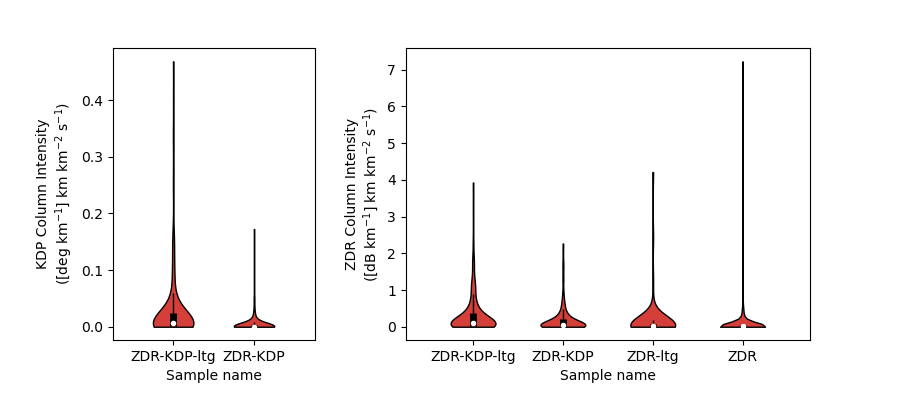

In [114]:
import matplotlib.pyplot as plt
import numpy as np


def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value


def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Sample name')

def decorate_parts(parts):
    for pc in parts['bodies']:
        pc.set_facecolor('#D43F3A')
        pc.set_edgecolor('black')
        pc.set_alpha(1)

def add_quartiles(data, ind, ax):
    sorted_array = sorted(data)
    quartile1, medians, quartile3 = np.percentile(sorted_array, [25, 50, 75])
    whiskers = adjacent_values(sorted_array, quartile1, quartile3)
    whiskers_min, whiskers_max = whiskers[0], whiskers[1]

    ax.scatter(ind, medians, marker='o', color='white', s=9, zorder=3)
    ax.vlines(ind, quartile1, quartile3, color='k', linestyle='-', lw=5)
    ax.vlines(ind, whiskers_min, whiskers_max, color='k', linestyle='-', lw=1)


fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, width_ratios=(2/6, 4/6), figsize=(9, 4))


# ax1.set_title('Default violin plot')
ax1.set_ylabel('KDP Column Intensity\n([deg km$^{-1}$] km km$^{-2}$ s$^{-1}$)')
parts = ax1.violinplot(violin_kdp_data, 
        showmeans=False, showmedians=False,
        showextrema=False)
decorate_parts(parts)
for i, data in enumerate(violin_kdp_data):
    add_quartiles(data, i+1, ax1)

labels = ['ZDR-KDP-ltg', 'ZDR-KDP']
set_axis_style(ax1, labels)
# ax1.semilogy()

# ax2.set_title('Customized violin plot')
ax2.set_ylabel('ZDR Column Intensity\n([dB km$^{-1}$] km km$^{-2}$ s$^{-1}$)')
parts = ax2.violinplot(violin_zdr_data,
        showmeans=False, showmedians=False,
        showextrema=False)
decorate_parts(parts)
for i, data in enumerate(violin_zdr_data):
    add_quartiles(data, i+1, ax2)
# ax2.semilogy()

labels = ['ZDR-KDP-ltg', 'ZDR-KDP', 'ZDR-ltg', 'ZDR']
set_axis_style(ax2, labels)



plt.subplots_adjust(bottom=0.15, wspace=0.3)
plt.show()
fig.savefig('KDP-ZDR-violin.pdf')

# How many tracks were less than 35 dBZ?

In [78]:
reflectivity_thresh = 35.0
only_low_ref_tracks = df[df.max_reflectivity < reflectivity_thresh]
only_low_ref_tracks

feature_flash_count  feature_zdrvol  feature_kdpvol  \
date     track_id                                                        
20220702 472                       0.0             0.0             0.0   
20220714 87                        0.0             0.0             0.0   
20220806 286                       0.0             0.0             0.0   
20220813 366                       0.0             0.0             0.0   
20220825 462                       0.0             0.0             0.0   
         1183                      0.0             0.0             0.0   
         1570                      0.0             0.0             0.0   
20220827 278                       0.0             0.0             0.0   
20220915 248                       0.0             0.0             0.0   
         406                       0.0             0.0             0.0   
         815                       0.0             0.0             0.0   
         836                       0.0             0.0             0.0   
         1145                      0.0             0.0             0.0   

                   feature_flash_count_area_time_norm  \
date     track_id                                       
20220702 472                                      0.0   
20220714 87                                       0.0   
20220806 286                                      0.0   
20220813 366                                      0.0   
20220825 462                                      0.0   
         1183                                     0.0   
         1570                                     0.0   
20220827 278                                      0.0   
20220915 248                                      0.0   
         406                                      0.0   
         815                                      0.0   
         836                                      0.0   
         1145                                     0.0   

                   feature_zdrvol_area_time_norm  \
date     track_id                                  
20220702 472                                 0.0   
20220714 87                                  0.0   
20220806 286                                 0.0   
20220813 366                                 0.0   
20220825 462                                 0.0   
         1183                                0.0   
         1570                                0.0   
20220827 278                                 0.0   
20220915 248                                 0.0   
         406                                 0.0   
         815                                 0.0   
         836                                 0.0   
         1145                                0.0   

                   feature_kdpvol_area_time_norm  \
date     track_id                                  
20220702 472                                 0.0   
20220714 87                                  0.0   
20220806 286                                 0.0   
20220813 366                                 0.0   
20220825 462                                 0.0   
         1183                                0.0   
         1570                                0.0   
20220827 278                                 0.0   
20220915 248                                 0.0   
         406                                 0.0   
         815                                 0.0   
         836                                 0.0   
         1145                                0.0   

                   feature_rhvdeficitvol_area_time_norm  \
date     track_id                                         
20220702 472                                        0.0   
20220714 87                                         0.0   
20220806 286                                        0.0   
20220813 366                                        0.0   
20220825 462                                        0.0   
         1183                                       0.0   
         1570     

In [79]:
print("Tracks with dBZ less than", reflectivity_thresh)
for kind, subset in track_membership.items():
    df_sub = df[subset.values]
    df_sub = df_sub[df_sub.max_reflectivity < reflectivity_thresh]
    print(kind, len(df_sub))

Tracks with dBZ less than 35.0
track_has_zdr_kdp_ltg 0
track_has_zdr_kdp_only 0
track_has_zdr_ltg_only 0
track_has_zdr_only 0
track_has_nothing 13
track_has_kdp_only 0
track_has_kdp_ltg_only 0
track_has_ltg_only 0
